### Parallel Computing Time

Computer Specs:

Intel Core Ultra 7 155h, Base Clock 3.8 GHz/Boost Clock 4.8 GHz, 16 cores 22 logical processors (6P + 8E + 2LPE), Laptop

Convergence time:

n = 1: 375.765259 s

n = 2: 155.9145569 s

n = 4: 110.1436129 s

n = 6: 91.7290781 s

n = 8: 86.2146201 s

n = 10: 72.2971652 s

n = 12: 68.9254474 s

n = 14: 64.5674345 s

n = 16: 60.2200777 s

n = 18: 62.114193 s

n = 20: 110.4508361 s

n = 22: 586.0229412 s

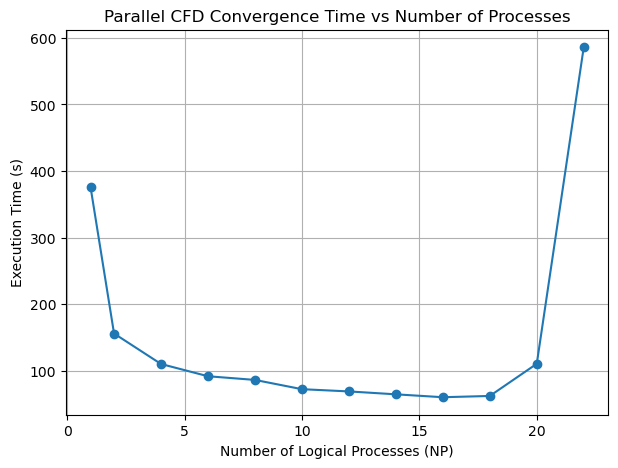

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# number of processes
n = np.array([1,2,4,6,8,10,12,14,16,18,20,22])

# convergence times (seconds)
time = np.array([
    375.765259,
    155.9145569,
    110.1436129,
    91.7290781,
    86.2146201,
    72.2971652,
    68.9254474,
    64.5674345,
    60.2200777,
    62.114193,
    110.4508361,
    586.0229412
])

plt.figure(figsize=(7,5))
plt.plot(n, time, marker='o')

plt.xlabel("Number of Logical Processes (NP)")
plt.ylabel("Execution Time (s)")
plt.title("Parallel CFD Convergence Time vs Number of Processes")
plt.grid(True)

# save to data directory
plt.savefig("Outputs/parallel_convergence_time.pdf", bbox_inches="tight")

plt.show()

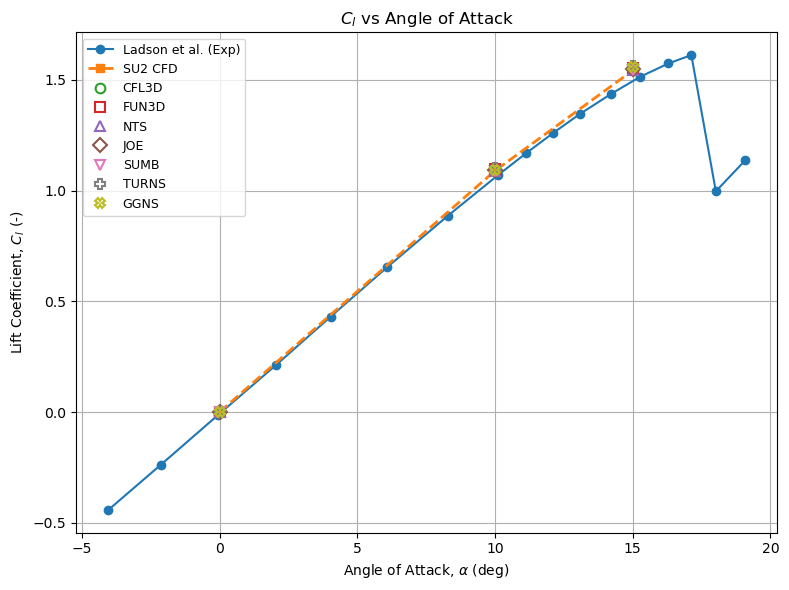

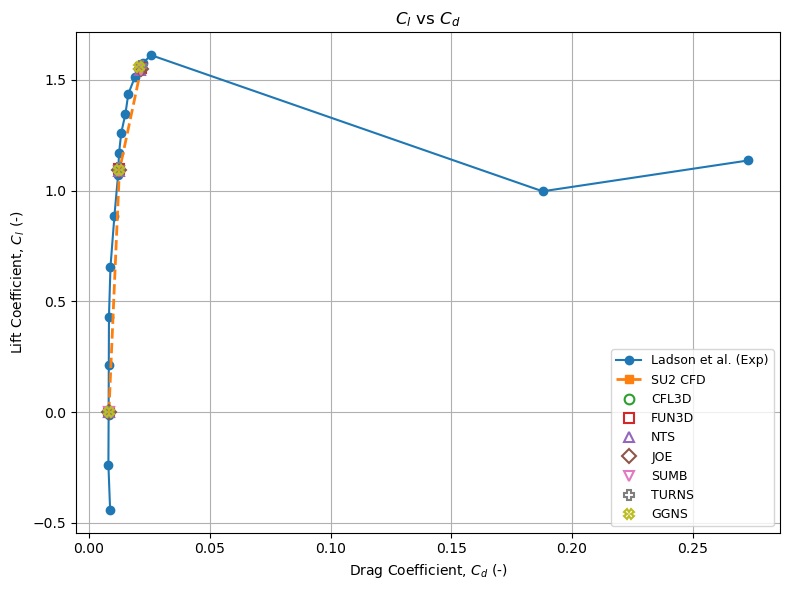

Final SU2 CFD values:
alpha =  0 deg : Cl = -0.000009, Cd = 0.008199
alpha = 10 deg : Cl = 1.089314, Cd = 0.012537
alpha = 15 deg : Cl = 1.542057, Cd = 0.021352

Saved files:
Outputs/Cl_vs_alpha.pdf
Outputs/Cl_vs_Cd.pdf


In [ ]:
import pandas as pd
import os

# ----------------------------
# file paths
# ----------------------------
hist_0_file = "Data/a=0 history.csv"
hist_10_file = "Data/a=10 history.csv"
hist_15_file = "Data/a=15 history.csv"
ladson_file = "Data/LadsonClCd-1.csv"

import os

output_dir = "Outputs"

os.makedirs(output_dir, exist_ok=True)

# ----------------------------
# helper to read SU2 history.csv
# ----------------------------
def get_final_cl_cd(filename):
    df = pd.read_csv(filename)

    # use exact headers from your files
    cd_col = '   "CD(airfoil)"  '
    cl_col = '   "CL(airfoil)"  '

    cl_final = df[cl_col].iloc[-1]
    cd_final = df[cd_col].iloc[-1]

    return cl_final, cd_final

# ----------------------------
# CFD data from your SU2 runs
# ----------------------------
alphas_cfd = [0, 10, 15]

cl_0, cd_0 = get_final_cl_cd(hist_0_file)
cl_10, cd_10 = get_final_cl_cd(hist_10_file)
cl_15, cd_15 = get_final_cl_cd(hist_15_file)

cl_cfd = [cl_0, cl_10, cl_15]
cd_cfd = [cd_0, cd_10, cd_15]

# ----------------------------
# experimental Ladson data
# ----------------------------
ladson = pd.read_csv(ladson_file)

alpha_exp = ladson["alpha"]
cl_exp = ladson["Cl"]
cd_exp = ladson["Cd"]

# ----------------------------
# NASA CFD package data from Lab 3 Table 1
# open symbols requested in the lab
# ----------------------------
codes = {
    "CFL3D": {"Cl": [0.0, 1.0909, 1.5461], "Cd": [0.00819, 0.01231, 0.02124], "marker": "o"},
    "FUN3D": {"Cl": [0.0, 1.0983, 1.5547], "Cd": [0.00812, 0.01242, 0.02159], "marker": "s"},
    "NTS":   {"Cl": [0.0, 1.0891, 1.5461], "Cd": [0.00813, 0.01243, 0.02105], "marker": "^"},
    "JOE":   {"Cl": [0.0, 1.0918, 1.5490], "Cd": [0.00812, 0.01245, 0.02148], "marker": "D"},
    "SUMB":  {"Cl": [0.0, 1.0904, 1.5446], "Cd": [0.00813, 0.01233, 0.02141], "marker": "v"},
    "TURNS": {"Cl": [0.0, 1.1000, 1.5642], "Cd": [0.00830, 0.01230, 0.02140], "marker": "P"},
    "GGNS":  {"Cl": [0.0, 1.0941, 1.5576], "Cd": [0.00817, 0.01225, 0.02073], "marker": "X"},
}

# ----------------------------
# Plot 1: Cl vs alpha
# ----------------------------
plt.figure(figsize=(8, 6))

# Ladson experiment
plt.plot(alpha_exp, cl_exp, marker='o', linestyle='-', label="Ladson et al. (Exp)")

# Your CFD
plt.plot(alphas_cfd, cl_cfd, marker='s', linestyle='--', linewidth=2, label="SU2 CFD")

# Other CFD packages as open symbols
for code_name, vals in codes.items():
    plt.plot(
        alphas_cfd,
        vals["Cl"],
        linestyle='None',
        marker=vals["marker"],
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=1.5,
        label=code_name
    )

plt.xlabel(r"Angle of Attack, $\alpha$ (deg)")
plt.ylabel(r"Lift Coefficient, $C_l$ (-)")
plt.title(r"$C_l$ vs Angle of Attack")
plt.grid(True)
plt.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.savefig(f"{output_dir}/Cl_vs_alpha.pdf", bbox_inches="tight")
plt.show()

# ----------------------------
# Plot 2: Cl vs Cd
# ----------------------------
plt.figure(figsize=(8, 6))

# Ladson experiment
plt.plot(cd_exp, cl_exp, marker='o', linestyle='-', label="Ladson et al. (Exp)")

# Your CFD
plt.plot(cd_cfd, cl_cfd, marker='s', linestyle='--', linewidth=2, label="SU2 CFD")

# Other CFD packages as open symbols
for code_name, vals in codes.items():
    plt.plot(
        vals["Cd"],
        vals["Cl"],
        linestyle='None',
        marker=vals["marker"],
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=1.5,
        label=code_name
    )

plt.xlabel(r"Drag Coefficient, $C_d$ (-)")
plt.ylabel(r"Lift Coefficient, $C_l$ (-)")
plt.title(r"$C_l$ vs $C_d$")
plt.grid(True)
plt.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.savefig(f"{output_dir}/Cl_vs_Cd.pdf", bbox_inches="tight")
plt.show()

# ----------------------------
# print final SU2 values
# ----------------------------
print("Final SU2 CFD values:")
for a, cl, cd in zip(alphas_cfd, cl_cfd, cd_cfd):
    print(f"alpha = {a:>2} deg : Cl = {cl:.6f}, Cd = {cd:.6f}")

print("\nSaved files:")
print(f"{output_dir}/Cl_vs_alpha.pdf")
print(f"{output_dir}/Cl_vs_Cd.pdf")

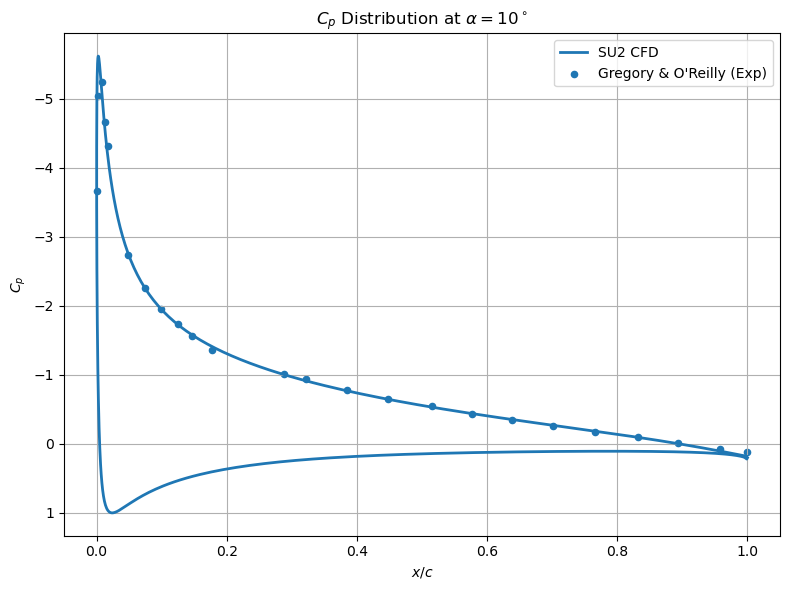

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# directories
data_dir = "Data"
output_dir = "Outputs"
os.makedirs(output_dir, exist_ok=True)

# files
su2_file = os.path.join(data_dir, "a=10 surface_flow.csv")
exp_file = os.path.join(data_dir, "GregoryCp.csv")

# load data
su2 = pd.read_csv(su2_file)
exp = pd.read_csv(exp_file)

# SU2 data
x_su2 = su2["x"]
cp_su2 = su2["Pressure"] / 0.5   # convert pressure to Cp per lab instructions

# experimental data
x_exp = exp["x/c"]
cp_exp = exp["Cp"]

# plot
plt.figure(figsize=(8, 6))

plt.plot(x_su2, cp_su2, linewidth=2, label="SU2 CFD")
plt.scatter(x_exp, cp_exp, s=20, label="Gregory & O'Reilly (Exp)")

plt.xlabel(r"$x/c$")
plt.ylabel(r"$C_p$")
plt.title(r"$C_p$ Distribution at $\alpha = 10^\circ$")
plt.grid(True)
plt.legend()

# aerodynamic convention: more negative Cp appears higher
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Cp_vs_xc_AOA10.pdf"), bbox_inches="tight")
plt.show()